# Taller Análisis Exploratorio de Datos
Estudiante:
# **Natalia Flórez Guzmán**

## **Paso 1: Carga de datos**

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A0
','A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
    '/content/crx.data',
    header=None,
    names=[
        'A0', 'A1', 'A2', 'A3',
        'A4', 'A5', 'A6', 'A7',
        'A8', 'A9', 'A10', 'A11',
        'A12', 'A13', 'A14', 'A15'
    ],
    na_values='?'
)

df.head()

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


# **¿Cuántas filas y columnas tiene el dataframe?**
El dataframe tiene 690 filas y 16 columnas. Las filas representan los registros del dataset y las columnas representan las diferentes variables que describen cada registro.

# **¿De qué tipo de dato es cada columna?**

El dataframe contiene:

10 columnas de tipo object, que corresponden a variables categóricas o de texto.

4 columnas de tipo float64, que corresponden a valores numéricos con decimales.

2 columnas de tipo int64, que corresponden a valores numéricos enteros.

# **¿Las variables están en el tipo de dato correcto para su contenido?**

Sí. Después de cargar los datos indicando que los valores ? que representan los datos faltantes (NaN), Pandas identificó correctamente los tipos de datos. Las variables categóricas quedaron como tipo object y las variables numéricas como float64 e int64, por lo que los datos tienen un formato adecuado para continuar con el análisis

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    object 
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      690 non-null    object 
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     690 non-null    object 
 12  A12     690 non-null    object 
 13  A13     677 non-null    float64
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


## **Paso 2: Exploración inicial de los datos**

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

# **¿Hay valores fuera de rango o imposibles, según el dominio del problema?**


Al revisar el resumen estadístico de las variables numéricas no se encontraron valores negativos ni datos que parezcan imposibles. Los valores mínimos y máximos se encuentran dentro de rangos razonables para las variables del dataset. Sin embargo, algunas variables como A14 presentan valores más dispersos.

In [59]:
df.describe()

,A1,A2,A7,A10,A13,A14
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000



# **¿Hay variables que no varían?**

Al revisar la cantidad de valores diferentes de cada variable, se encontró que ninguna columna tiene siempre el mismo valor. Todas las variables cambian entre los registros, por lo que pueden aportar información útil para el análisis.

In [60]:
df.nunique()

,0
A0,2
A1,349
A2,215
A3,3
A4,3
A5,14
A6,9
A7,132
A8,2
A9,2



# **¿Qué variables cualitativas tienen muchos valores únicos (alta cardinalidad)?**

Al revisar las variables cualitativas, se encontró que la mayoría tienen pocas categorías diferentes. La variable con más valores únicos es A5 con 14 categorías, seguida de A6 con 9 categorías y A3, A4 Y A12 con 3 categorías. Sin embargo, ninguna variable presenta una cantidad muy alta de categorías, por lo que no se considera que exista un problema de alta cardinalidad en los datos.

In [61]:
df.select_dtypes(include='object').nunique()

,0
A0,2
A3,3
A4,3
A5,14
A6,9
A8,2
A9,2
A11,2
A12,3
A15,2


# **¿Hay claves primarias o identificadores únicos?**

No se encontraron claves primarias ni identificadores únicos en el dataset. Ninguna variable tiene un valor diferente para cada registro, ya que la cantidad de valores únicos de todas las columnas es menor al número total de filas (690).

In [62]:
df.nunique()

,0
A0,2
A1,349
A2,215
A3,3
A4,3
A5,14
A6,9
A7,132
A8,2
A9,2


## **Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo**

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

# **¿Qué variables tienen valores nulos? ¿En qué proporción?**

Al revisar los datos faltantes del dataset, se encontraron valores nulos en las variables A0, A1, A3, A4, A5, A6 y A13. La variable con más datos faltantes es A13 con 13 valores (1.88%),  seguida de A0 y A1 con 12 valores cada una (1.74%). En general, la cantidad de datos faltantes es baja, ya que ninguna variable supera el 2% de valores nulos respecto al total de registros.

In [63]:
df.isnull().sum()

,0
A0,12
A1,12
A2,0
A3,6
A4,6
A5,9
A6,9
A7,0
A8,0
A9,0


In [64]:
(df.isnull().sum() / len(df)) * 100

,0
A0,1.739130
A1,1.739130
A2,0.000000
A3,0.869565
A4,0.869565
A5,1.304348
A6,1.304348
A7,0.000000
A8,0.000000
A9,0.000000


# **¿Hay registros duplicados?**

Al revisar los registros duplicados, se encontró que no existen filas repetidas en el dataset. El resultado fue 0 duplicados, por lo tanto cada registro es diferente y no es necesario eliminar datos duplicados.

In [65]:
df.duplicated().sum()

np.int64(0)

# **¿Hay variables con problemas de formato (fechas, monedas, mayúsculas/minúsculas)?**

Al revisar las variables del dataset no se encontraron problemas de formato. No existen fechas, monedas o valores con diferencias de escritura entre mayúsculas y minúsculas. Las variables categóricas mantienen un formato uniforme, por lo que no requieren ajustes en esta etapa.


In [66]:
df.select_dtypes(include='object').head()

,A0,A3,A4,A5,A6,A8,A9,A11,A12,A15
0,b,u,g,w,v,t,t,f,g,+
1,a,u,g,q,h,t,t,f,g,+
2,a,u,g,q,h,t,f,f,g,+
3,b,u,g,w,v,t,t,t,g,+
4,b,u,g,w,v,t,f,f,s,+


## **Paso 4: Análisis de variables cuantitativas**

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

# **¿Qué variables cuantitativas tiene el dataset?**
Las variables cuantitativas encontradas fueron:

A1,
A2,
A7,
A10,
A13,
A14,

Estas variables contienen datos numéricos y permiten realizar análisis estadísticos.

In [67]:
df.select_dtypes(include=['int64','float64']).columns

Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='object')

# **Análisis gráfico de distribución (Histogramas)**
Se realizaron histogramas para observar la distribución de las variables cuantitativas. Se encontró que las variables no presentan una distribución completamente uniforme y algunas muestran concentración de datos en ciertos rangos.

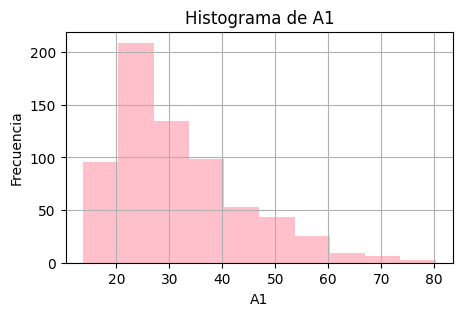

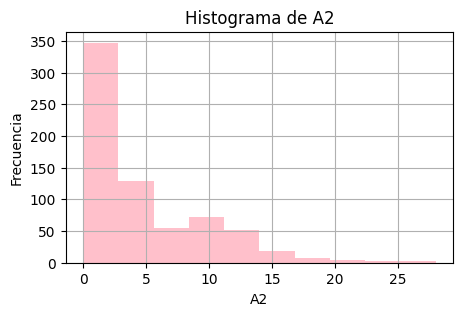

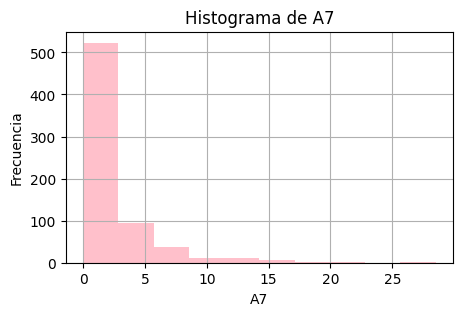

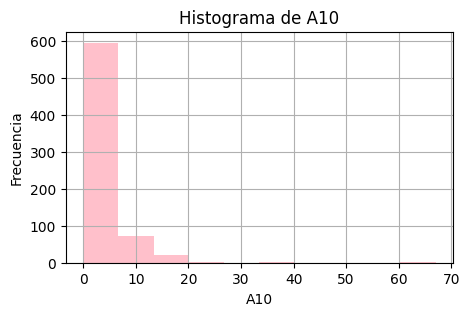

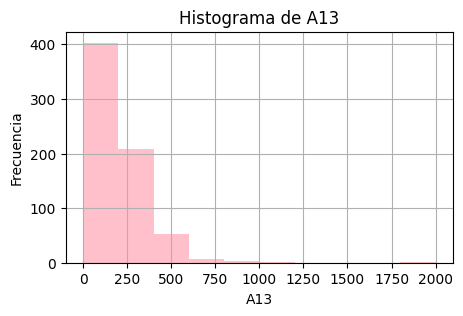

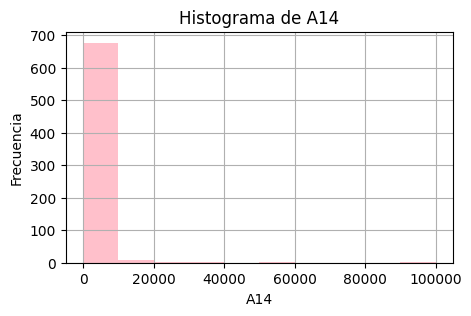

In [68]:
variables_numericas = ['A1','A2','A7','A10','A13','A14']

for variable in variables_numericas:
    plt.figure(figsize=(5,3))
    df[variable].hist(color='pink')
    plt.title(f"Histograma de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

# **Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.**

Se realizó la prueba de normalidad de Shapiro-Wilk para las variables cuantitativas A1, A2, A7, A10, A13 y A14. Los resultados muestran que todas tienen un p-valor menor a 0.05, por lo que ninguna variable sigue una distribución normal.

In [69]:
from scipy.stats import shapiro
variables_numericas = ['A1','A2','A7','A10','A13','A14']

for variable in variables_numericas:
    stat, p = shapiro(df[variable].dropna())
    print(variable, "p-valor:", p)

A1 p-valor: 8.814177720874041e-20
A2 p-valor: 2.009391244299927e-26
A7 p-valor: 1.1096840819543244e-34
A10 p-valor: 3.662317517782373e-39
A13 p-valor: 8.376486244549668e-27
A14 p-valor: 1.4053433496862405e-47


# **Haga un análisis gráfico de outliers y, como resultado de este, indique qué variables tienen datos atípicos.**

**Análisis gráfico de outliers**

Se realizó un análisis gráfico mediante diagramas de caja (boxplot) para las variables cuantitativas A1, A2, A7, A10, A13 y A14 con el fin de identificar posibles valores atípicos.

Al observar los gráficos, se encontraron algunos datos alejados del comportamiento general de las variables. La variable A14 presenta la mayor cantidad de valores extremos, con registros que se encuentran muy por encima del resto de los datos. La variable A13 también presenta algunos valores atípicos, aunque en menor cantidad.

Las demás variables pueden presentar algunos valores alejados, pero no muestran una cantidad significativa de datos fuera de sus límites. Estos valores deben tenerse en cuenta, ya que pueden influir en análisis posteriores y en la construcción de modelos predictivos.

# **Análisis gráfico de valores atípicos (Boxplot)**

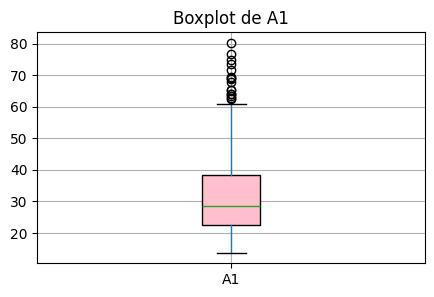

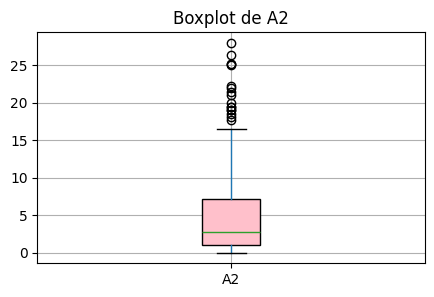

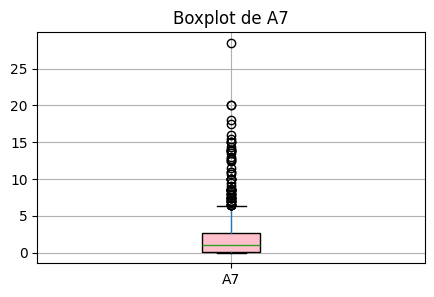

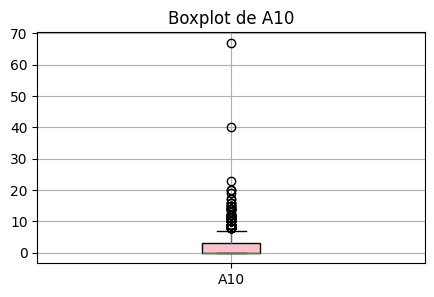

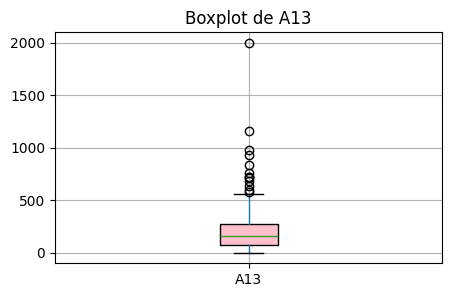

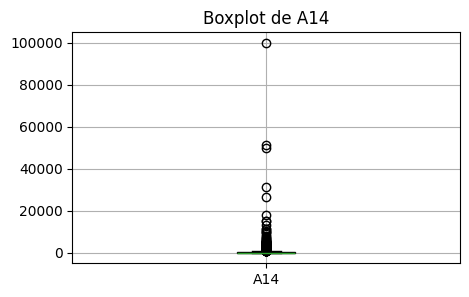

In [70]:
import matplotlib.pyplot as plt

variables_numericas = ['A1','A2','A7','A10','A13','A14']

for variable in variables_numericas:
    plt.figure(figsize=(5,3))

    box = df.boxplot(
        column=variable,
        patch_artist=True,
        boxprops=dict(facecolor='pink')
    )

    plt.title(f"Boxplot de {variable}")
    plt.show()

## **Paso 5: Análisis de variables cualitativas**

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

# **¿Cómo se comportan las variables categóricas?**
Las variables categóricas tienen pocas categorías diferentes en la mayoría de los casos. Algunas variables solo tienen dos opciones, como A0, A8, A9, A11 y A15, mientras que otras tienen más variedad, como A5 con 14 categorías y A6 con 9 categorías.

También se observa que algunas categorías aparecen mucho más que otras. Por ejemplo, en la variable A12 la categoría g aparece en 625 registros, siendo la más común. Esto muestra que algunas opciones son más frecuentes dentro de los datos, mientras que otras aparecen menos veces.

In [71]:
df.select_dtypes(include='object').describe()

,A0,A3,A4,A5,A6,A8,A9,A11,A12,A15
count,678,684,684,681,681,690,690,690,690,690
unique,2,3,3,14,9,2,2,2,3,2
top,b,u,g,c,v,t,f,f,g,-
freq,468,519,519,137,399,361,395,374,625,383


# **¿Existen variables de alta cardinalidad?**

Para revisar si existen variables con alta cardinalidad primero se analizó la cantidad de valores diferentes que tiene cada variable categórica. Los resultados muestran que la mayoría de variables tienen pocas categorías, entre 2 y 3 valores únicos.

Las variables con mayor cantidad de categorías son A5 con 14 valores diferentes y A6 con 9 valores diferentes. Sin embargo, al comparar estas cantidades con el tamaño del dataset (690 registros), no representan una cantidad alta de categorías.

Por lo tanto, no se encontraron variables con alta cardinalidad. Aunque A5 y A6 tienen más categorías que las demás variables, la cantidad de valores únicos sigue siendo baja y no representa un problema para el análisis de los datos

In [72]:
df.select_dtypes(include='object').nunique()

,0
A0,2
A3,3
A4,3
A5,14
A6,9
A8,2
A9,2
A11,2
A12,3
A15,2


# **¿Existen categorías atípicas?**
Al revisar la frecuencia de las categorías se encontraron algunos valores con muy pocos registros. Las categorías menos frecuentes se encuentran principalmente en las variables A3, A4, A5, A6 y A12.Por ejemplo, en A3 y A4 algunas categorías aparecen solo 2 veces, y en A5 y A6 existen categorías con muy pocos registros. Estas categorías pueden considerarse atípicas porque tienen una baja presencia frente a las demás categorías de la variable. Por ejemplo, en A3 y A4 existen categorías que aparecen únicamente 2 veces. Estas categorías deben revisarse porque una baja cantidad de datos puede afectar el análisis de las variables.

In [73]:
for columna in df.select_dtypes(include='object').columns:
    print("\nVariable:", columna)
    print(df[columna].value_counts())


Variable: A0
A0
b    468
a    210
Name: count, dtype: int64

Variable: A3
A3
u    519
y    163
l      2
Name: count, dtype: int64

Variable: A4
A4
g     519
p     163
gg      2
Name: count, dtype: int64

Variable: A5
A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64

Variable: A6
A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64

Variable: A8
A8
t    361
f    329
Name: count, dtype: int64

Variable: A9
A9
f    395
t    295
Name: count, dtype: int64

Variable: A11
A11
f    374
t    316
Name: count, dtype: int64

Variable: A12
A12
g    625
s     57
p      8
Name: count, dtype: int64

Variable: A15
A15
-    383
+    307
Name: count, dtype: int64


## **Paso 6: Análisis bivariado**

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


# **Relación de variables cuantitativas con A15**
se realizaron gráficos de caja para comparar las variables cuantitativas A1, A2, A7, A10, A13 y A14 con la variable objetivo A15. Al observar los resultados, se encontraron algunas diferencias entre los grupos + y -.

La variable A7 muestra una diferencia más clara, ya que los valores del grupo + tienden a ser más altos que los del grupo -. La variable A2 también presenta cierta diferencia entre ambos grupos.

En el caso de A1, aunque existen algunas diferencias entre los grupos, hay bastante similitud entre las distribuciones. Por otro lado, A10 y A13 tienen comportamientos más parecidos entre las dos categorías, por lo que no se observa una relación tan fuerte con A15. La variable A14 presenta muchos valores extremos en ambos grupos, especialmente en la categoria +, lo que puede afectar la interpretacion de los resultados.

En general, las variables A7 y A2 parecen tener una mayor relación con A15, mientras que A10 y A13 muestran menor diferencia entre los grupos.

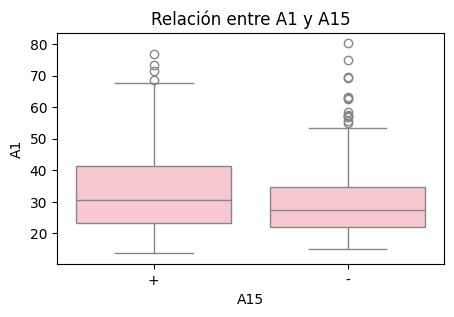

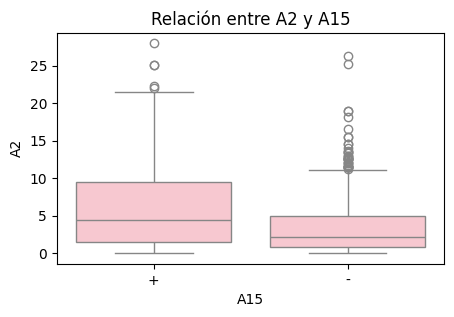

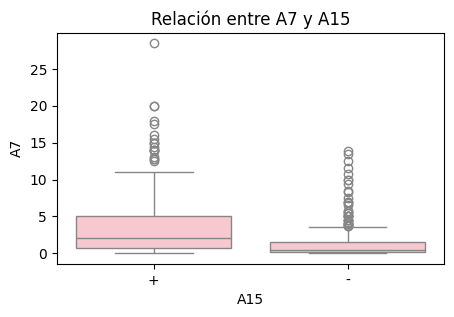

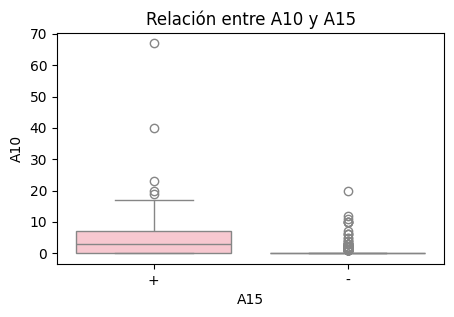

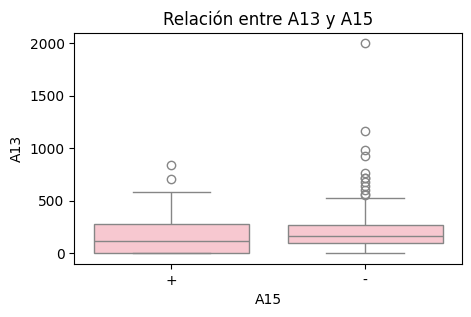

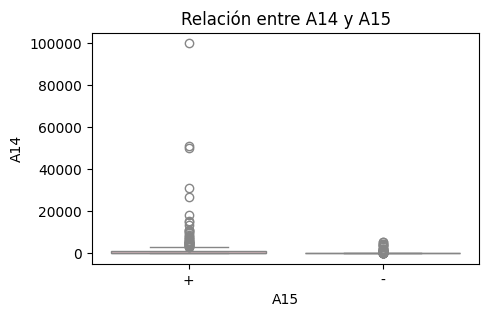

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_numericas = ['A1','A2','A7','A10','A13','A14']

for variable in variables_numericas:
    plt.figure(figsize=(5,3))

    sns.boxplot(
        x='A15',
        y=variable,
        data=df,
        color='pink'
    )

    plt.title(f'Relación entre {variable} y A15')
    plt.xlabel('A15')
    plt.ylabel(variable)
    plt.show()

# **Relación de variables cualitativas con A15**
Al revisar los gráficos de barras de las variables cualitativas con respecto a A15, se observa que algunas variables tienen diferencias entre los grupos + y -, mientras que otras se comportan de manera similar.

Las variables A8 y A9 muestran una relación más clara con A15, ya que algunas de sus categorías aparecen con mayor frecuencia en uno de los dos grupos. Por ejemplo, en A8, la categoría t aparece más en los casos positivos (+), mientras que la categoría f aparece más en los casos negativos (-).

Variables como A3, A4, A6 y A12 también presentan algunas diferencias entre sus categorías, aunque algunas tienen pocos registros y esto puede hacer que los resultados sean menos representativos.

Por otro lado, A0 y A11 tienen un comportamiento más parecido entre los grupos + y -, por lo que no parece existir una relación tan fuerte con la variable que se quiere predecir.

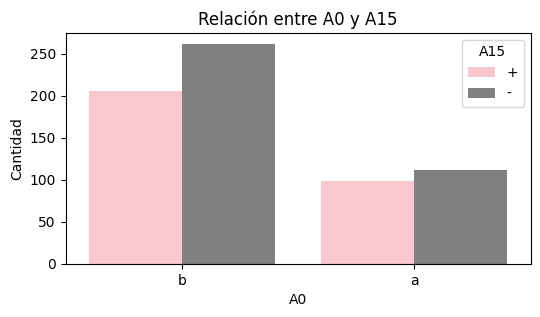

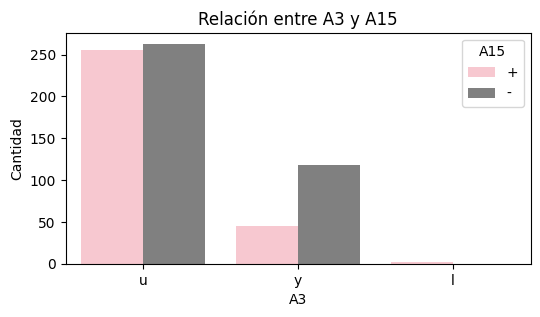

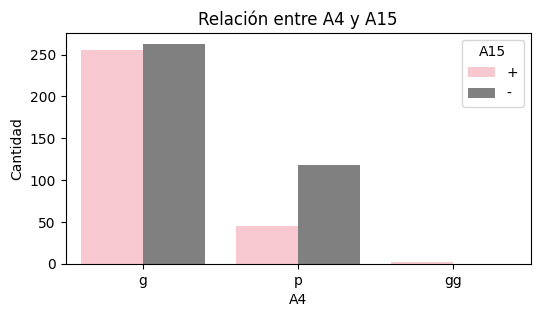

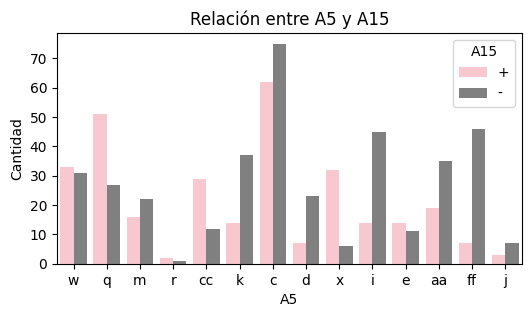

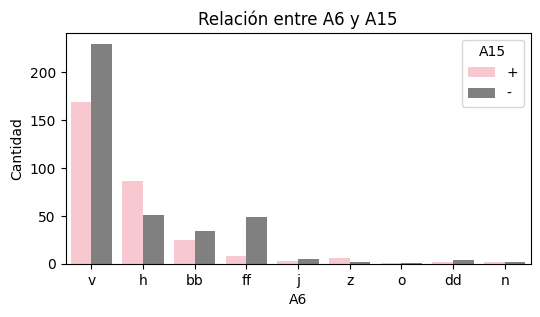

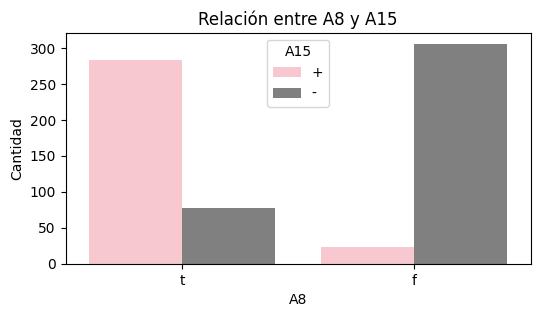

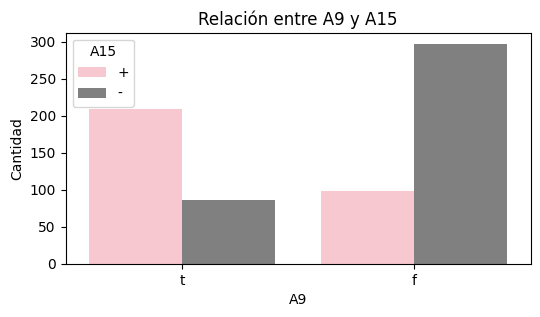

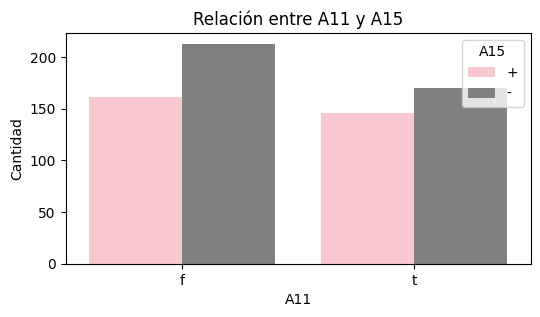

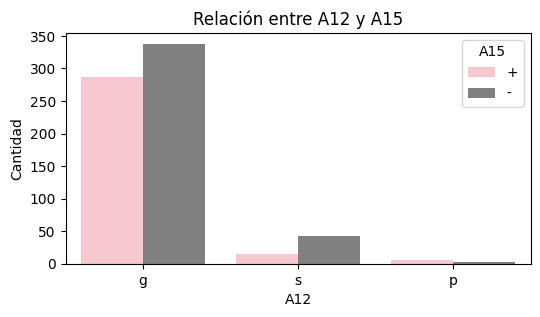

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_categoricas = ['A0','A3','A4','A5','A6','A8','A9','A11','A12']

for variable in variables_categoricas:
    plt.figure(figsize=(6,3))

    sns.countplot(
        x=variable,
        hue='A15',
        data=df,
        palette=['pink', 'gray']
    )

    plt.title(f'Relación entre {variable} y A15')
    plt.xlabel(variable)
    plt.ylabel('Cantidad')
    plt.show()

# **Conclusión: ¿Cuáles variables parecen ser buenas predictoras y cuáles no?**

De acuerdo con los análisis realizados, las variables que parecen tener mayor relación con la variable objetivo A15 son A7, A2, A8 y A9, ya que presentan diferencias más claras entre los grupos + y -.

Otras variables como A3, A4, A6 y A12 podrían aportar información, pero algunas categorías tienen pocos registros. Por otro lado, variables como A10, A13, A0 y A11 parecen tener menor relación con A15 debido a que sus distribuciones son más similares entre las clases.

La variable A14 debe revisarse porque presenta muchos valores extremos que pueden afectar el análisis y el desempeño de un modelo predictivo.